In [1]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os

data_type = 'float32'

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pickle

import tqdm
from tqdm import tqdm

import xgboost
from xgboost import XGBClassifier


merged_features = pd.read_csv('../spermatid_info_0.008_vif_5.csv', index_col=0)

In [2]:
y = merged_features['age']
features = list(merged_features.columns)
features.remove('age')
X = merged_features[features]

In [3]:
cont_ftrs = features

In [4]:
def ML_pipeline_GridSearchCV(X, y, clf, param_grid, random_state, n_folds, xgbc=False, set_random=True):
    '''
    clf: classifier
    param_grid: parameter grid
    '''
    # create a test set based on groups
    random_state = 42*random_state
    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, random_state = random_state)
    
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    # standard scaler for continuous feature
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, cont_ftrs)])

    
    if xgbc:
        clf.set_params(seed=random_state)
    if set_random:
        clf.set_params(random_state=random_state)
        
    # create the pipeline: preprocessor + supervised ML method
    pipe = make_pipeline(preprocessor, clf)
    
    # prepare gridsearch
    grid = GridSearchCV(pipe, param_grid=param_grid, scoring=make_scorer(accuracy_score),
                        cv=kf, return_train_score=True, n_jobs=-1)
    
    # do kfold CV on _other
    grid.fit(X_other, y_other)

    return grid, grid.score(X_test, y_test)


In [5]:
import xgboost
from xgboost import XGBClassifier

In [6]:
xgbc = XGBClassifier(use_label_encoder=False)
param_grid = {'xgbclassifier__max_depth': [5],
              "xgbclassifier__learning_rate": [0.03, 0.05],
              'xgbclassifier__n_estimators': [8000],
              'xgbclassifier__colsample_bytree': [0.8],
              'xgbclassifier__subsample': [0.66, 0.75],
              'xgbclassifier__objective': ['multi:softmax'],
              'xgbclassifier__eval_metric': ['mlogloss']}

In [7]:
models_xgbc = []
for i in tqdm(range(10)):
    grid, test_score = ML_pipeline_GridSearchCV(X, y, xgbc, param_grid, i, 5, xgbc=True)
    print(grid.best_params_)
    print('best CV score:', grid.best_score_)
    print('test score:',test_score)
    models_xgbc.append(grid)

 10%|███████▌                                                                   | 1/10 [4:44:43<42:42:33, 17083.70s/it]

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__eval_metric': 'mlogloss', 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__objective': 'multi:softmax', 'xgbclassifier__subsample': 0.66}
best CV score: 0.7765824614868778
test score: 0.7921146953405018


 20%|███████████████                                                            | 2/10 [9:20:23<37:15:08, 16763.60s/it]

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__eval_metric': 'mlogloss', 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__objective': 'multi:softmax', 'xgbclassifier__subsample': 0.66}
best CV score: 0.77788562503216
test score: 0.7800586510263929


 30%|██████████████████████▏                                                   | 3/10 [13:56:15<32:24:30, 16667.15s/it]

...

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__eval_metric': 'mlogloss', 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__objective': 'multi:softmax', 'xgbclassifier__subsample': 0.75}
best CV score: 0.7738124048687293
test score: 0.7862495927012056


 90%|███████████████████████████████████████████████████████████████████▌       | 9/10 [41:56:11<4:38:41, 16721.36s/it]

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__eval_metric': 'mlogloss', 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__objective': 'multi:softmax', 'xgbclassifier__subsample': 0.75}
best CV score: 0.7776417902024544
test score: 0.7790811339198436


100%|████████████████████████████████████████████████████████████████████████████| 10/10 [46:33:05<00:00, 16758.57s/it]

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__eval_metric': 'mlogloss', 'xgbclassifier__learning_rate': 0.03, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 8000, 'xgbclassifier__objective': 'multi:softmax', 'xgbclassifier__subsample': 0.75}
best CV score: 0.7787012849049807
test score: 0.7823395242750082


In [14]:
file = open('../spermatid_info_0.008_vif_5.save', 'wb')
pickle.dump(models_xgbc, file)
file.close()
    
# save the test_sets
test_sets = []
for i in range(10):
    random_state = 42*i
    # since the same random states are used for all models, 
    # we can recapitulate the test sets in individual state and check accuracies
    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, random_state = random_state)
    test_sets.append((X_test, y_test))

file = open('../spermatid_info_0.008_vif_5_test_sets.save', 'wb')
pickle.dump((test_sets),file)
file.close()

# save the train_sets
train_sets = []
for i in range(10):
    random_state = 42*i
    # since the same random states are used for all models, 
    # we can recapitulate the test sets in individual state and check accuracies
    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, random_state = random_state)
    train_sets.append((X_other, y_other))

file = open('../spermatid_info_0.008_vif_5_train_sets.save', 'wb')
pickle.dump((train_sets),file)
file.close()

# fit transform the features once, and store it
feature_names = cont_ftrs
file = open('../spermatid_info_0.008_vif_5_feature_names.save', 'wb')
pickle.dump((feature_names),file)
file.close()

In [15]:
# test
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os
data_type = 'float32'
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pickle
import tqdm
from tqdm import tqdm

In [16]:
file = open('../spermatid_info_0.008_vif_5.save', 'rb')
xgbt = pickle.load(file)
file.close()

file = open('../spermatid_info_0.008_vif_5_test_sets.save', 'rb')
test_sets = pickle.load(file)
file.close()

file = open('../spermatid_info_0.008_vif_5_feature_names.save', 'rb')
feature_names = pickle.load(file)
file.close()

In [17]:
from sklearn.metrics import confusion_matrix
def get_cm(model, nrun):
    
    aa = 0
    ab = 0
    ac = 0
    ad = 0
    ae = 0
    ba = 0
    bb = 0
    bc = 0
    bd = 0
    be = 0
    ca = 0
    cb = 0
    cc = 0
    cd = 0
    ce = 0
    da = 0
    db = 0
    dc = 0
    dd = 0
    de = 0
    ea = 0
    eb = 0
    ec = 0
    ed = 0
    ee = 0
    
    for i in range(nrun):
        X_test, y_test = test_sets[i]
        
        clf = model[i]
        
        y_pred = clf.predict(X_test)
        
        # calculate the sum of tn, fp, fn, tp to get the mean values to calculate cm
        cm = confusion_matrix(y_test, y_pred)

        aa += cm[0,0]
        ab += cm[0,1]
        ac += cm[0,2]
        ad += cm[0,3]
        ae += cm[0,4]
        aa += cm[1,0]
        bb += cm[1,1]
        bc += cm[1,2]
        bd += cm[1,3]
        be += cm[1,4]
        ca += cm[2,0]
        cb += cm[2,1]
        cc += cm[2,2]
        cd += cm[2,3]
        ce += cm[2,4]
        da += cm[3,0]
        db += cm[3,1]
        dc += cm[3,2]
        dd += cm[3,3]
        de += cm[3,4]
        ea += cm[4,0]
        eb += cm[4,1]
        ec += cm[4,2]
        ed += cm[4,3]
        ee += cm[4,4]
         
    # mean tn, fp, fn, tp --> cm (mean)
    cm = np.array([[aa/nrun, ab/nrun, ac/nrun, ad/nrun, ae/nrun], 
                   [ba/nrun, bb/nrun, bc/nrun, bd/nrun, be/nrun],
                  [ca/nrun, cb/nrun, cc/nrun, cd/nrun, ce/nrun],
                  [da/nrun, db/nrun, dc/nrun, dd/nrun, de/nrun],
                  [ea/nrun, eb/nrun, ec/nrun, ed/nrun, ee/nrun]])
    
    # normalize
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    return cm

def plot_cm(cm, classes):    
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='viridis')
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title='Normalized (mean) confusion matrix(for Xgboost)',
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' 
    thresh = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="black" if cm[i, j] == thresh else "white")
    fig.tight_layout()
    return ax

In [18]:
cm = get_cm(xgbt, 10)
cm

array([[0.69644985, 0.00571837, 0.05384799, 0.04336431, 0.20061949],
       [0.        , 0.59073234, 0.22488658, 0.13609851, 0.04828257],
       [0.01908448, 0.02775924, 0.80208194, 0.10182837, 0.04924596],
       [0.01775873, 0.02357624, 0.14895897, 0.7601041 , 0.04960196],
       [0.03591985, 0.0057557 , 0.03869111, 0.03176295, 0.88787039]])

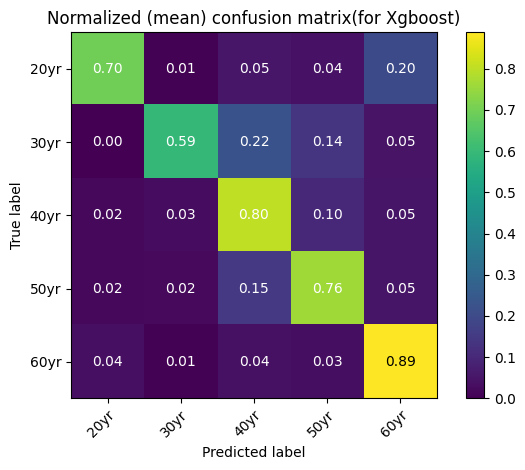

In [19]:
plot_cm(cm, classes=['20yr','30yr', '40yr', '50yr', '60yr'])
plt.show()

In [20]:
from sklearn.inspection import permutation_importance

np.random.seed(42)
ftr_names = feature_names
nr_runs = 10
scores = np.zeros([len(ftr_names),nr_runs])
X_test5, y_test5 = test_sets[5]
X_test = X_test5
y_test = y_test5
grid = xgbt[5]
# loop through the features
for i in range(len(ftr_names)):
    print('shuffling '+ str(ftr_names[i]))
    acc_scores = []
    for j in range(nr_runs):
        X_test_shuffled = X_test.copy()
        X_test_shuffled[ftr_names[i]] = np.random.permutation(X_test[ftr_names[i]].values)
        acc_scores.append(grid.score(X_test_shuffled,y_test))
    print('   shuffled test score:',np.around(np.mean(acc_scores),3),'+/-',np.around(np.std(acc_scores),3))
    scores[i] = acc_scores

shuffling CCDC27
   shuffled test score: 0.777 +/- 0.0
shuffling SPEN
   shuffled test score: 0.777 +/- 0.0
shuffling CLCNKB
   shuffled test score: 0.772 +/- 0.002
shuffling ATP5IF1
   shuffled test score: 0.777 +/- 0.001
shuffling C1orf94
   shuffled test score: 0.777 +/- 0.001
shuffling TMCO2
   shuffled test score: 0.775 +/- 0.002
shuffling CITED4
   shuffled test score: 0.773 +/- 0.002
shuffling YBX1
   shuffled test score: 0.77 +/- 0.001
shuffling ATP6V0B
   shuffled test score: 0.776 +/- 0.0
shuffling P3R3URF
   shuffled test score: 0.767 +/- 0.002
shuffling C1orf185
   shuffled test score: 0.776 +/- 0.001
shuffling AC119428.1
   shuffled test score: 0.777 +/- 0.0
shuffling TMEM59
   shuffled test score: 0.777 +/- 0.001
shuffling PLPP3
   shuffled test score: 0.777 +/- 0.0
shuffling NFIA-AS1
   shuffled test score: 0.777 +/- 0.001
shuffling ASB17
   shuffled test score: 0.777 +/- 0.001
shuffling LINC01760
   shuffled test score: 0.777 +/- 0.001
shuffling TXNIP
   shuffled test s

   shuffled test score: 0.776 +/- 0.001
shuffling AC073111.1
   shuffled test score: 0.769 +/- 0.002
shuffling AC006019.1
   shuffled test score: 0.772 +/- 0.002
shuffling EGR3
   shuffled test score: 0.777 +/- 0.0
shuffling AC009623.1
   shuffled test score: 0.776 +/- 0.001
shuffling AC044849.1
   shuffled test score: 0.777 +/- 0.0
shuffling TEX15
   shuffled test score: 0.777 +/- 0.001
shuffling EFCAB1
   shuffled test score: 0.776 +/- 0.002
shuffling PENK
   shuffled test score: 0.777 +/- 0.0
shuffling MYBL1
   shuffled test score: 0.777 +/- 0.0
shuffling LINC01609
   shuffled test score: 0.777 +/- 0.0
shuffling RNF139-AS1
   shuffled test score: 0.775 +/- 0.001
shuffling LINC00964
   shuffled test score: 0.777 +/- 0.0
shuffling SCRT1
   shuffled test score: 0.777 +/- 0.0
shuffling DMRT1
   shuffled test score: 0.777 +/- 0.0
shuffling EQTN
   shuffled test score: 0.777 +/- 0.0
shuffling CCIN
   shuffled test score: 0.777 +/- 0.001
shuffling AL158154.3
   shuffled test score: 0.777 +

   shuffled test score: 0.777 +/- 0.0
shuffling CFD
   shuffled test score: 0.776 +/- 0.001
shuffling TLE5
   shuffled test score: 0.777 +/- 0.0
shuffling MIR7-3HG
   shuffled test score: 0.777 +/- 0.0
shuffling MBD3L1
   shuffled test score: 0.776 +/- 0.001
shuffling AC008543.5
   shuffled test score: 0.777 +/- 0.0
shuffling CALR
   shuffled test score: 0.777 +/- 0.0
shuffling CALR3
   shuffled test score: 0.776 +/- 0.001
shuffling RPL18A
   shuffled test score: 0.775 +/- 0.001
shuffling JUND
   shuffled test score: 0.772 +/- 0.002
shuffling SPINT2
   shuffled test score: 0.776 +/- 0.0
shuffling RPS19
   shuffled test score: 0.774 +/- 0.002
shuffling SRRM5
   shuffled test score: 0.776 +/- 0.001
shuffling ZNF428
   shuffled test score: 0.776 +/- 0.001
shuffling ZSWIM9
   shuffled test score: 0.777 +/- 0.0
shuffling SPACA4
   shuffled test score: 0.776 +/- 0.001
shuffling FTL
   shuffled test score: 0.76 +/- 0.003
shuffling PRMT1
   shuffled test score: 0.776 +/- 0.0
shuffling IZUMO2
 

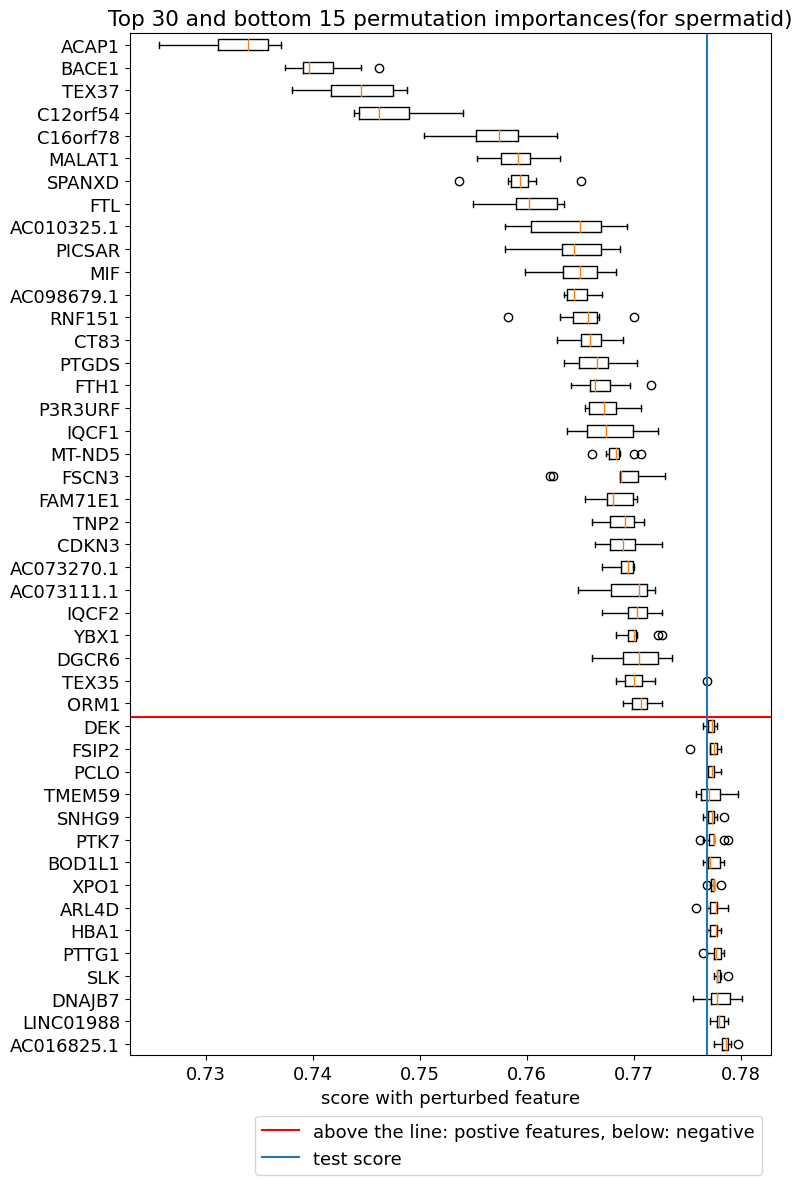

In [21]:
test_score = grid.score(X_test,y_test)
sorted_indcs = np.argsort(np.mean(scores,axis=1))[::-1]
top15 = sorted_indcs[-30:]
low15 = sorted_indcs[:15]
tl15 = np.append(low15, top15)
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 12))
plt.boxplot(scores[tl15].T,labels=np.array(ftr_names)[tl15],vert=False)
plt.axhline(y= 15.4, color='r', label='above the line: postive features, below: negative')
plt.axvline(test_score, label='test score')
plt.title("Top 30 and bottom 15 permutation importances(for spermatid)")
plt.xlabel('score with perturbed feature')
plt.legend(bbox_to_anchor=(1, -0.05))
plt.tight_layout()
plt.savefig('../spermatid_info_0.008_vif_5_permutation_importance.png')
plt.show()